# 🔬 Logistická regrese – Úvod, teorie a praktická implementace
### Kurz Data Science & Machine Learning | Coders Lab (09/2026)
> **Zdrojový výukový materiál:** `Logistic_regression_-_introduction_and_implementation.pdf`  
> Tento sešit pokrývá kompletní teorii a praktickou realizaci logistické regrese pro Den 2:
> 1. Porovnání lineární a logistické regrese (proč OLS selhává při binární klasifikaci).
> 2. Sigmoidální funkce a matematická formulace pravděpodobnosti $p(\mathbf{x})$.
> 3. Klinický onkologický příklad z kurzu (predikce malignity tumoru z věku a průměru).
> 4. Ztrátová funkce Log Loss (Cross-Entropy) a optimalizace metodou maximální věrohodnosti (MLE).
> 5. Školní implementace v Scikit-learn na syntetickém datasetu (`make_classification`, 600 vzorků, 5 příznaků).
> 6. Analýza rozhodovacího prahu (Threshold Sweep) a optimalizace pro medicínské aplikace.
> 7. Aplikace na reálná klinická data bederní páteře (`lumbar_df_normalized.csv`) a srovnání s k-NN.


## 1. Školní úloha: Syntetická data a Scikit-learn implementace
Přesná reprodukce kroků ze slajdů 18–21:
- Vygenerování datasetu pomocí `make_classification(n_samples=600, n_features=5, n_classes=2, random_state=42)`
- Rozdělení dat na trénovací a testovací sadu v poměru 70:30 (`train_test_split`)
- Inicializace a natrénování `LogisticRegression`
- Predikce a výpočet základních metrik (`accuracy_score`, `precision_score`)

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, log_loss

# 1. Vytvoření syntetického klasifikačního datasetu (slajd 18)
df = make_classification(n_samples=600, n_features=5, n_classes=2, random_state=42)

X = df[0]  # 0: nezávislé proměnné
y = df[1]  # 1: cílová proměnná (target)

# 2. Rozdělení na trénovací a testovací sadu (slajd 19)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Inicializace a trénování modelu (slajdy 19-20)
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# 4. Predikce a metriky na testovací sadě (slajd 21)
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
ll = log_loss(y_test, y_prob)

print("=== VÝSLEDKY ŠKOLNÍHO MODELU (Slajd 21) ===")
print(f"Accuracy score : {accuracy:.4f} ({accuracy*100:.2f} %)")
print(f"Precision score: {precision:.4f} ({precision*100:.2f} %)")
print(f"Recall score   : {recall:.4f} ({recall*100:.2f} %)")
print(f"F1-score       : {f1:.4f} ({f1*100:.2f} %)")
print(f"Log Loss       : {ll:.4f}")


=== VÝSLEDKY ŠKOLNÍHO MODELU (Slajd 21) ===
Accuracy score : 0.9389 (93.89 %)
Precision score: 0.9451 (94.51 %)
Recall score   : 0.9348 (93.48 %)
F1-score       : 0.9399 (93.99 %)
Log Loss       : 0.1545


## 2. Matice záměn (Confusion Matrix)
Zobrazíme matici záměn pro syntetický model a zkontrolujeme rozložení True Positives, True Negatives, False Positives a False Negatives.

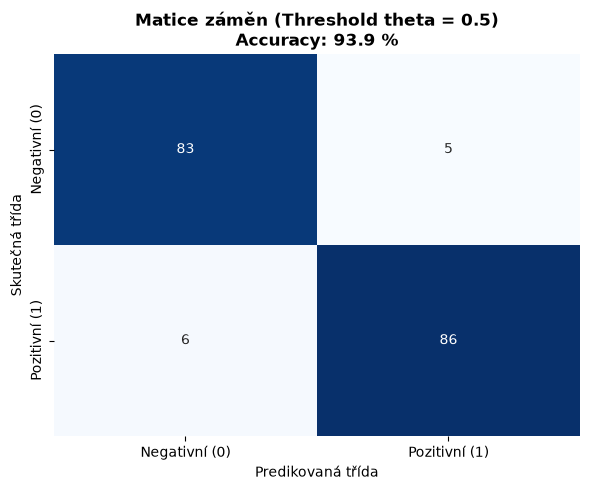

TN: 83 | FP: 5 (Falešný poplach)
FN: 6  | TP: 86 (Správný záchyt)


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Negativní (0)", "Pozitivní (1)"],
            yticklabels=["Negativní (0)", "Pozitivní (1)"])
plt.title(f"Matice záměn (Threshold theta = 0.5)\nAccuracy: {accuracy*100:.1f} %", fontsize=12, fontweight="bold")
plt.xlabel("Predikovaná třída")
plt.ylabel("Skutečná třída")
plt.tight_layout()
plt.show()

print(f"TN: {tn} | FP: {fp} (Falešný poplach)")
print(f"FN: {fn}  | TP: {tp} (Správný záchyt)")


## 3. Geometrické srovnání: Lineární OLS vs. Logistická regrese (Slajdy 4–6)
Proč běžná lineární regrese selhává při predikci pravděpodobností?
1. Predikce OLS $\hat{y} = \mathbf{x}^T \boldsymbol{\beta}$ mohou přesáhnout interval $[0, 1]$ (výsledky $<0$ nebo $>1$).
2. Logistická regrese provádí nelineární stlačení pomocí sigmoidy: $\sigma(z) = \frac{1}{1 + e^{-z}} \in (0, 1)$.

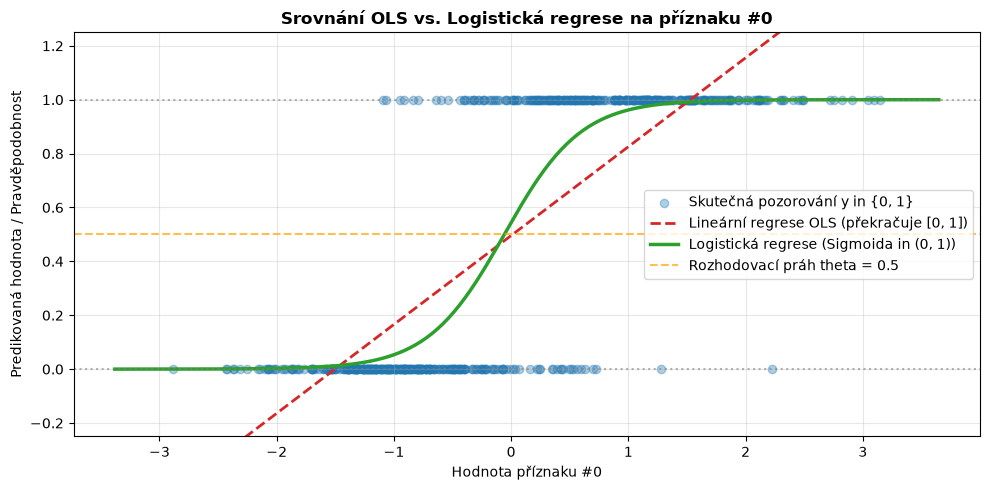

In [3]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Vybereme dominantní příznak pro 1D demonstraci
best_feat_idx = int(np.argmax(np.abs(log_reg.coef_[0])))
x_1d = X[:, best_feat_idx]

# Natrénujeme OLS na 1D datech
lin_reg = LinearRegression()
lin_reg.fit(x_1d.reshape(-1, 1), y)

# Natrénujeme 1D logistickou regresi
log_reg_1d = LogisticRegression()
log_reg_1d.fit(x_1d.reshape(-1, 1), y)

# Generování jemné mřížky pro vykreslení křivek
x_grid = np.linspace(x_1d.min() - 0.5, x_1d.max() + 0.5, 300)
y_lin_grid = lin_reg.predict(x_grid.reshape(-1, 1))
y_log_grid = log_reg_1d.predict_proba(x_grid.reshape(-1, 1))[:, 1]

plt.figure(figsize=(10, 5))
plt.scatter(x_1d, y, alpha=0.35, color="#1f77b4", label="Skutečná pozorování y in {0, 1}")
plt.plot(x_grid, y_lin_grid, color="#d62728", linestyle="--", linewidth=2, label="Lineární regrese OLS (překračuje [0, 1])")
plt.plot(x_grid, y_log_grid, color="#2ca02c", linewidth=2.5, label="Logistická regrese (Sigmoida in (0, 1))")
plt.axhline(0, color="gray", linestyle=":", alpha=0.6)
plt.axhline(1, color="gray", linestyle=":", alpha=0.6)
plt.axhline(0.5, color="orange", linestyle="--", alpha=0.7, label="Rozhodovací práh theta = 0.5")

plt.title(f"Srovnání OLS vs. Logistická regrese na příznaku #{best_feat_idx}", fontsize=12, fontweight="bold")
plt.xlabel(f"Hodnota příznaku #{best_feat_idx}")
plt.ylabel("Predikovaná hodnota / Pravděpodobnost")
plt.ylim(-0.25, 1.25)
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Klinický příklad ze slajdu 10: Diagnostika malignity tumoru
Matematické zadání ze slajdů kurzu:
- $x_1$: Věk pacienta ($50\text{ let}$)
- $x_2$: Průměr tumoru ($35\text{ mm}$)
- Koeficienty: $a_1 = 0.005$, $a_2 = 0.015$, intercept $b = 0.1$
- Lineární index: $z = 0.005 \cdot 50 + 0.015 \cdot 35 + 0.1 = 0.875$
- Pravděpodobnost: $p(x) = \frac{1}{1 + e^{-0.875}} \approx 0.706$ (70.6 %)

=== VÝPOČET ONKOLOGICKÉHO PŘÍKLADU ZE SLAJDU 10 ===
Věk pacienta      : 50 let
Průměr tumoru     : 35 mm
Lineární index z  : 0.8750
Pravděpodobnost p : 0.7058 (70.58 %)


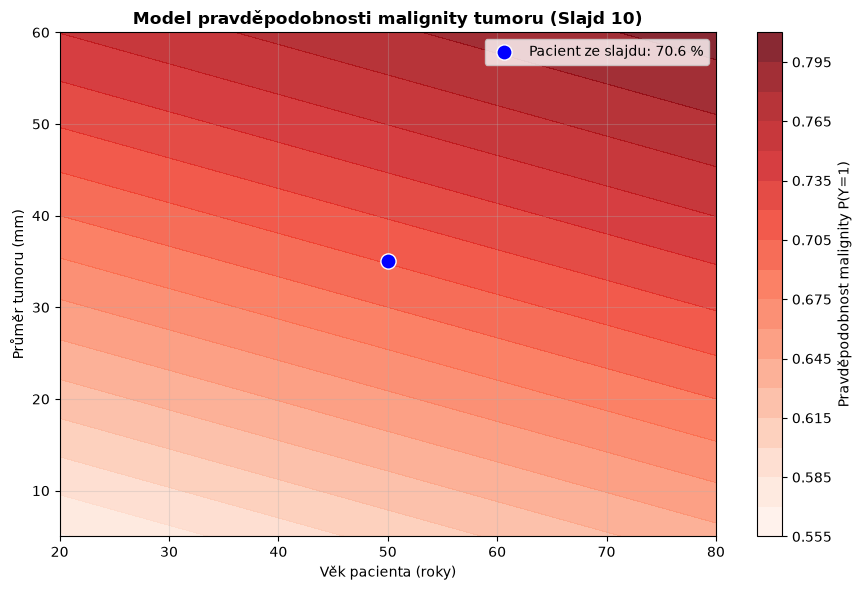

In [4]:
# Reprodukce výpočtu ze slajdu 10
age = 50
diameter = 35

a1 = 0.005
a2 = 0.015
b = 0.1

z = a1 * age + a2 * diameter + b
prob = 1.0 / (1.0 + np.exp(-z))

print("=== VÝPOČET ONKOLOGICKÉHO PŘÍKLADU ZE SLAJDU 10 ===")
print(f"Věk pacienta      : {age} let")
print(f"Průměr tumoru     : {diameter} mm")
print(f"Lineární index z  : {z:.4f}")
print(f"Pravděpodobnost p : {prob:.4f} ({prob*100:.2f} %)")

# 2D vrstevnicový graf pravděpodobnosti malignity
ages = np.linspace(20, 80, 100)
diams = np.linspace(5, 60, 100)
A, D = np.meshgrid(ages, diams)
Z = a1 * A + a2 * D + b
P = 1.0 / (1.0 + np.exp(-Z))

plt.figure(figsize=(9, 6))
contour = plt.contourf(A, D, P, levels=20, cmap="Reds", alpha=0.85)
cbar = plt.colorbar(contour)
cbar.set_label("Pravděpodobnost malignity P(Y=1)")

# Vyznačení rozhodovací hranice theta = 0.5 (kde z = 0)
plt.contour(A, D, P, levels=[0.5], colors="black", linestyles="--", linewidths=2)
# Bod pacienta ze slajdu
plt.scatter([age], [diameter], color="blue", s=120, edgecolors="white", zorder=5, label=f"Pacient ze slajdu: {prob*100:.1f} %")

plt.title("Model pravděpodobnosti malignity tumoru (Slajd 10)", fontsize=12, fontweight="bold")
plt.xlabel("Věk pacienta (roky)")
plt.ylabel("Průměr tumoru (mm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Vliv rozhodovacího prahu (Threshold Tuning, Slajd 11)
Výchozí hranice $\theta = 0.5$ nemusí být optimální. V medicínských úlohách dáváme přednost vysokému **Recall** (nechceme přehlédnout nemocného pacienta), i za cenu poklesu **Precision**.

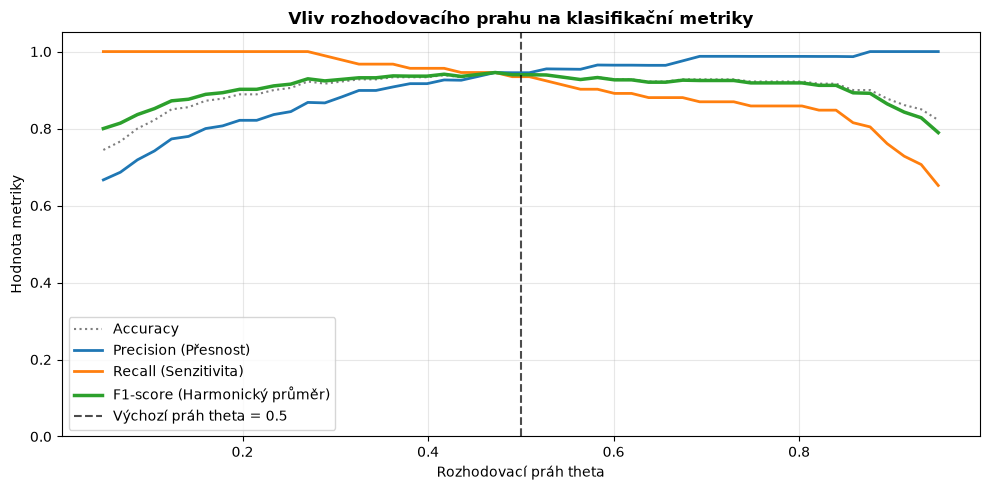

In [5]:
thresholds = np.linspace(0.05, 0.95, 50)
accuracies, precisions, recalls, f1_scores = [], [], [], []

for th in thresholds:
    y_pred_th = (y_prob >= th).astype(int)
    accuracies.append(accuracy_score(y_test, y_pred_th))
    precisions.append(precision_score(y_test, y_pred_th, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_th, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_th, zero_division=0))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, accuracies, label="Accuracy", color="#7f7f7f", linestyle=":")
plt.plot(thresholds, precisions, label="Precision (Přesnost)", color="#1f77b4", linewidth=2)
plt.plot(thresholds, recalls, label="Recall (Senzitivita)", color="#ff7f0e", linewidth=2)
plt.plot(thresholds, f1_scores, label="F1-score (Harmonický průměr)", color="#2ca02c", linewidth=2.5)

plt.axvline(0.5, color="black", linestyle="--", alpha=0.7, label="Výchozí práh theta = 0.5")
plt.title("Vliv rozhodovacího prahu na klasifikační metriky", fontsize=12, fontweight="bold")
plt.xlabel("Rozhodovací práh theta")
plt.ylabel("Hodnota metriky")
plt.ylim(0, 1.05)
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Aplikace na data kurzu: Bederní páteř (`lumbar_df_normalized.csv`)
Otestujeme logistickou regresi na reálných datech biomechaniky bederní páteře (310 pacientů, 6 úhlů) a porovnáme výsledky s modelem k-NN z předchozích cvičení.

In [6]:
import os
from pathlib import Path
import pandas as pd
from sklearn.metrics import roc_auc_score

# Zjištění cesty k datasetu v rámci notebooku
possible_paths = [
    Path("data/lumbar_df_normalized.csv"),
    Path("lumbar_df_normalized.csv"),
    Path("../data/lumbar_df_normalized.csv")
]
lumbar_path = next((p for p in possible_paths if p.exists()), None)
if lumbar_path is None:
    raise FileNotFoundError("Dataset lumbar_df_normalized.csv nebyl nalezen.")

df_lumbar = pd.read_csv(lumbar_path)
feature_cols = [c for c in df_lumbar.columns if c != "class"]
X_l = df_lumbar[feature_cols].values
y_l = df_lumbar["class"].values

X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(
    X_l, y_l, test_size=0.25, random_state=42, stratify=y_l
)

log_lumb = LogisticRegression(random_state=42, C=1.0)
log_lumb.fit(X_tr_l, y_tr_l)

y_pred_l = log_lumb.predict(X_te_l)
y_prob_l = log_lumb.predict_proba(X_te_l)[:, 1]

acc_l = accuracy_score(y_te_l, y_pred_l)
rec_l = recall_score(y_te_l, y_pred_l)
prec_l = precision_score(y_te_l, y_pred_l)
f1_l = f1_score(y_te_l, y_pred_l)
auc_l = roc_auc_score(y_te_l, y_prob_l)

print("=== VÝSLEDKY LOGISTICKÉ REGRESE NA PÁTEŘI ===")
print(f"Accuracy : {acc_l*100:.2f} %")
print(f"Recall   : {rec_l*100:.2f} %")
print(f"Precision: {prec_l*100:.2f} %")
print(f"F1-score : {f1_l*100:.2f} %")
print(f"ROC-AUC  : {auc_l:.4f}")

# Výpis Odds Ratios (poměrů šancí)
print("\n=== INTERPRETACE KOEFICIENTŮ: POMĚRY ŠANCÍ (ODDS RATIOS) ===")
for col, coef in zip(feature_cols, log_lumb.coef_[0]):
    odds_ratio = np.exp(coef)
    print(f"{col:25s} | beta = {coef:+7.4f} | Odds Ratio = {odds_ratio:6.4f}")


=== VÝSLEDKY LOGISTICKÉ REGRESE NA PÁTEŘI ===
Accuracy : 71.79 %
Recall   : 88.68 %
Precision: 74.60 %
F1-score : 81.03 %
ROC-AUC  : 0.8460

=== INTERPRETACE KOEFICIENTŮ: POMĚRY ŠANCÍ (ODDS RATIOS) ===
pelvic_incidence          | beta = +1.0401 | Odds Ratio = 2.8295
pelvic_tilt numeric       | beta = +1.0486 | Odds Ratio = 2.8535
lumbar_lordosis_angle     | beta = +0.5692 | Odds Ratio = 1.7669
sacral_slope              | beta = -0.0085 | Odds Ratio = 0.9916
pelvic_radius             | beta = -1.8661 | Odds Ratio = 0.1547
degree_spondylolisthesis  | beta = +4.1114 | Odds Ratio = 61.0295


## 7. Závěrečné shrnutí a klíčové poznatky

1. **Logistická regrese je klasifikátor:**  
   Využívá lineární kombinaci $\mathbf{x}^T \boldsymbol{\beta}$ a transformuje ji sigmoidou do intervalu $(0, 1)$, což dává rigorózní interpretaci aposteriorní pravděpodobnosti $P(Y=1 \mid \mathbf{x})$.
2. **Optimalizace přes MLE a Log Loss:**  
   Namísto OLS se parametry hledají maximalizací věrohodnosti (minimalizací binární cross-entropy). Tím je zajištěna konvexní optimalizační úloha bez lokálních uvíznutí.
3. **Prahování (Cutoff Threshold):**  
   Výchozí hranice $\theta = 0.5$ se v klinické a byznysové praxi upravuje podle asymetrie nákladů na chyby (např. snížení prahu pro maximalizaci Recall u onkologických nálezů).
4. **Vysoká interpretovatelnost:**  
   Pomocí poměrů šancí ($\text{Odds Ratio} = \exp(\beta_j)$) dokážeme přesně kvantifikovat, jak zvýšení daného anatomického parametru násobí šanci na patologii páteře.
